In [1]:
from generate_utils import load_GraphModel, load_BiLSTMModel, load_TokenBiLSTMModel
from models_graph import HarmonicGraphEncoder
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

/home/maximos/miniconda3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [3]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/LoRA/graph/graph_model_contra_jnhw.pt'
bilstm_model_path = 'saved_models/LoRA/bilstm/bilstm_model_jnhw.pt'
token_model_path = 'saved_models/LoRA/token_bilstm/bilstm_model_jnhw.pt'

In [4]:
graph_model = load_GraphModel(graph_model_path, device)
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)
token_model = load_TokenBiLSTMModel(token_model_path, tokenizer, device)

In [5]:
graph_model.eval()
bilstm_model.eval()
token_model.eval()

TokenHarmonyBiLSTM(
  (embedding): Embedding(355, 256, padding_idx=0)
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=512, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
  )
)

In [6]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

In [7]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt
loading nott


In [8]:
graph_embeddings = []
bilstm_embeddings = []
token_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # bilstm
            g.make_bilstm_seq_of_segment(bar_start, bar_end)
            segment_bilstm = g.segment_bilstm.unsqueeze(0)
            lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            bilstm_embeddings.append(
                z_bilstm.detach().cpu().numpy()
            )
            # # token
            # z_token = token_model(segment_bilstm.to(device), lengths.to(device))
            # token_embeddings.append(
            #     z_token.detach().cpu().numpy()
            # )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
bilstm_embeddings = np.vstack(bilstm_embeddings)
# token_embeddings = np.vstack(token_embeddings)

28it [00:00, 28.03it/s]
45it [00:01, 29.81it/s]


In [9]:
print(graph_embeddings.shape)
print(bilstm_embeddings.shape)

(1054, 512)
(1054, 512)


In [10]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [11]:
# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@2_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@2m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]'

# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
# in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@2;C:maj_@2'
# in_seq_2 = 'b_G:9_@2;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@2;C:maj_@2'
# in_seq_4 = 'b_C#:7_@2;C:maj_@2'

# in_seq_1 = 'b_C:7_@2;F:maj_@2'
# in_seq_2 = 'b_C:9_@2;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@2;F:maj_@2'
# in_seq_4 = 'b_F#:7_@2;F:maj_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_C:7_@2;F:maj7_@2'
# in_seq_3 = 'b_F:7_@2;A#:maj7_@2'
# in_seq_4 = 'b_A#:7_@2;D#:maj7_@2'

# in_seq_1 = 'b_B:7_@2;E:maj7_@2'
# in_seq_2 = 'b_E:7_@2;A:maj7_@2'
# in_seq_3 = 'b_A:7_@2;D:maj7_@2'
# in_seq_4 = 'b_D:7_@2;G:maj7_@2'

in_seq_1 = 'b_G:7_@2;C:maj7_@2'
in_seq_2 = 'b_G:7_@2;D:maj7_@2'
in_seq_3 = 'b_G:sus4_@4b_G:sus4@4'
in_seq_4 = 'b_A:min11_@4b_A:min11_@4'

# in_seq_1 = 'b_D:7(b9)_@2;G:maj_@2'
# in_seq_2 = 'b_D:9_@2;G:maj_@2'
# in_seq_3 = 'b_F#:hdim7_@2;G:maj_@2'
# in_seq_4 = 'b_G#:7_@2;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model)
y_graph_3, m3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model, return_mel_harm=True)
y_graph_4, m4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model, return_mel_harm=True)

y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model)
y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model)
y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model)
y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model)

G:7 in vocab as: 216
C:maj7 in vocab as: 14
G:7 in vocab as: 216
D:maj7 in vocab as: 72
G:sus4 in vocab as: 214
unrecognized chord symbol G:sus4@4
A:min11 in vocab as: 285
A:min11 in vocab as: 285
G:7 in vocab as: 216
C:maj7 in vocab as: 14
G:7 in vocab as: 216
D:maj7 in vocab as: 72
G:sus4 in vocab as: 214
unrecognized chord symbol G:sus4@4
A:min11 in vocab as: 285
A:min11 in vocab as: 285


In [12]:
m3.print_info()

Number of bars: 2
Segment bar range: [0, 2)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=1,
    x=[1, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 3],
    edge_attr=[3, 5],
  },
  (event, next, event)={
    edge_index=[2, 0],
    edge_attr=[0],
  }
)
Segment graph bars:
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: G:sus4
Pitch classes: [0, 2, 7]
Root: 7
Chord ID: 214
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
Bar 2:
Bar token positions: []
Number of chord objects in bar: 0
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: G:sus4
Pitch classes: [0, 2, 7]
Root: 7
Chord ID: 214
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 0., 

In [13]:
m4.print_info()

Number of bars: 2
Segment bar range: [0, 2)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A:min11
Pitch classes: [0, 2, 4, 7, 9, 11]
Root: 9
Chord ID: 285
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.]])
BiLSTM Features
tensor([1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1.])
Bar 2:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A:min11
Pitch classes: [0, 2, 4, 7, 9, 11]
Root: 9
Chord ID: 285
Bar Positions: [0, 1]
Token

In [14]:
cos = torch.nn.CosineSimilarity()
print(cos(y_graph_3, y_graph_4))

tensor([-0.2103], device='cuda:0')


In [15]:
from sklearn.decomposition import PCA

In [16]:
pca_graph = PCA(n_components=2)
pca_bilstm = PCA(n_components=2)

In [17]:
y_graph = pca_graph.fit_transform(graph_embeddings)
y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [18]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

new_bilstm = np.vstack([
    y_bilstm_1.detach().cpu().numpy(),
    y_bilstm_2.detach().cpu().numpy(),
    y_bilstm_3.detach().cpu().numpy(),
    y_bilstm_4.detach().cpu().numpy(),
])

new_graph_2d = pca_graph.transform(new_graph)
new_bilstm_2d = pca_bilstm.transform(new_bilstm)

In [19]:
# print(y_graph.shape, y_bilstm.shape)

In [20]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
# import plotly.io as pio
# pio.renderers.default = "browser"

In [21]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
datasets_list = [metadata[i]['dataset'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_graph,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords'],
)
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [22]:
# chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_bilstm,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords']
)
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [23]:
d = datasets['gjt']['dataset'][17]
d['graph_ready_object'].make_graph_of_segment(13,15)
d['graph_ready_object'].make_bilstm_seq_of_segment(13,15)

In [24]:
g = graph_from_string(in_seq_4)

A:min11 in vocab as: 285
A:min11 in vocab as: 285


In [25]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [13, 15)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 14:
Bar token positions: [66, 67, 68, 69]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root: 10
Chord ID: 314
Bar Positions: [0, 1, 2, 3]
Token Positions: [66, 67, 68, 69]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.])
Bar 15:
Bar token positions: [71, 72, 73, 74]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root:

In [26]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [27]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [28]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].num_nodes, graph_string["event"].num_nodes)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
2 2
torch.Size([2, 12]) torch.Size([2, 12])


In [29]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 1], [0, 4], [1, 1], [1, 4], [2, 2]]']


In [30]:
print(graph_dataset["event"].num_nodes)
print(graph_string["event"].num_nodes)

2
2


In [31]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[1., 1., 1., 0., 0., 0.]])
tensor([[1., 1., 1., 0., 0., 0.]])


In [32]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [33]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [34]:
import matplotlib.pyplot as plt

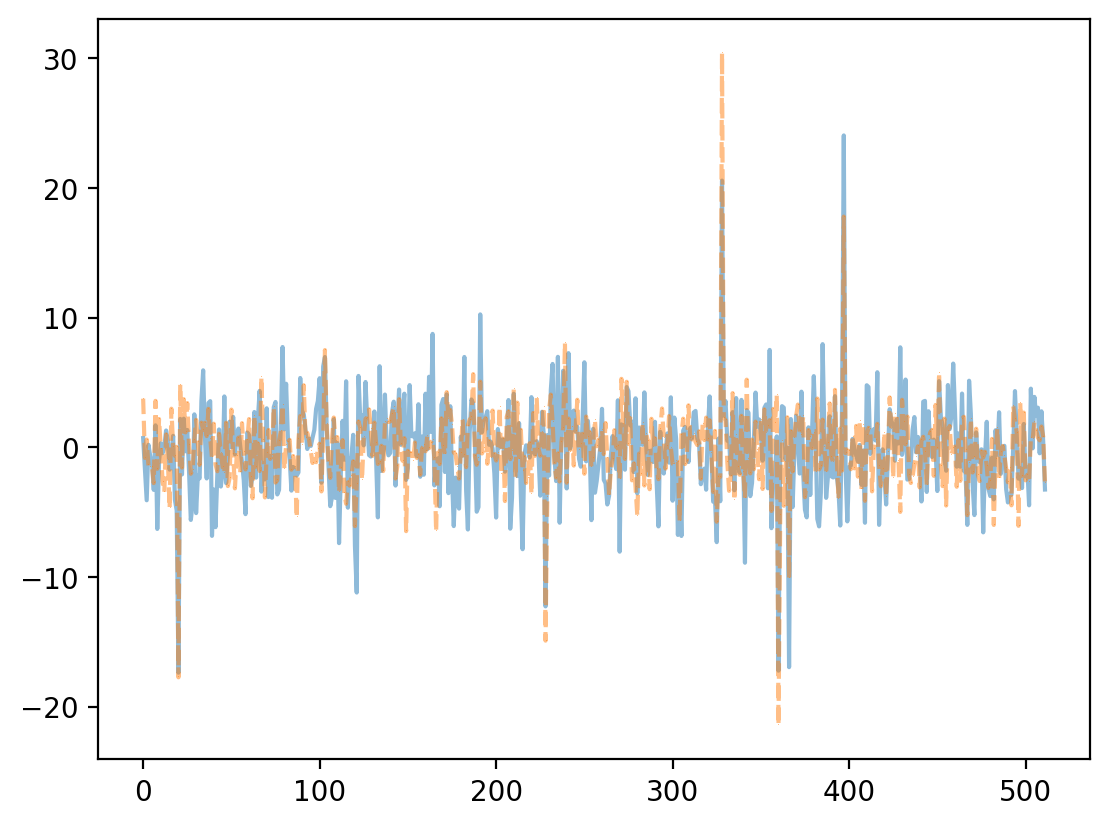

In [35]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

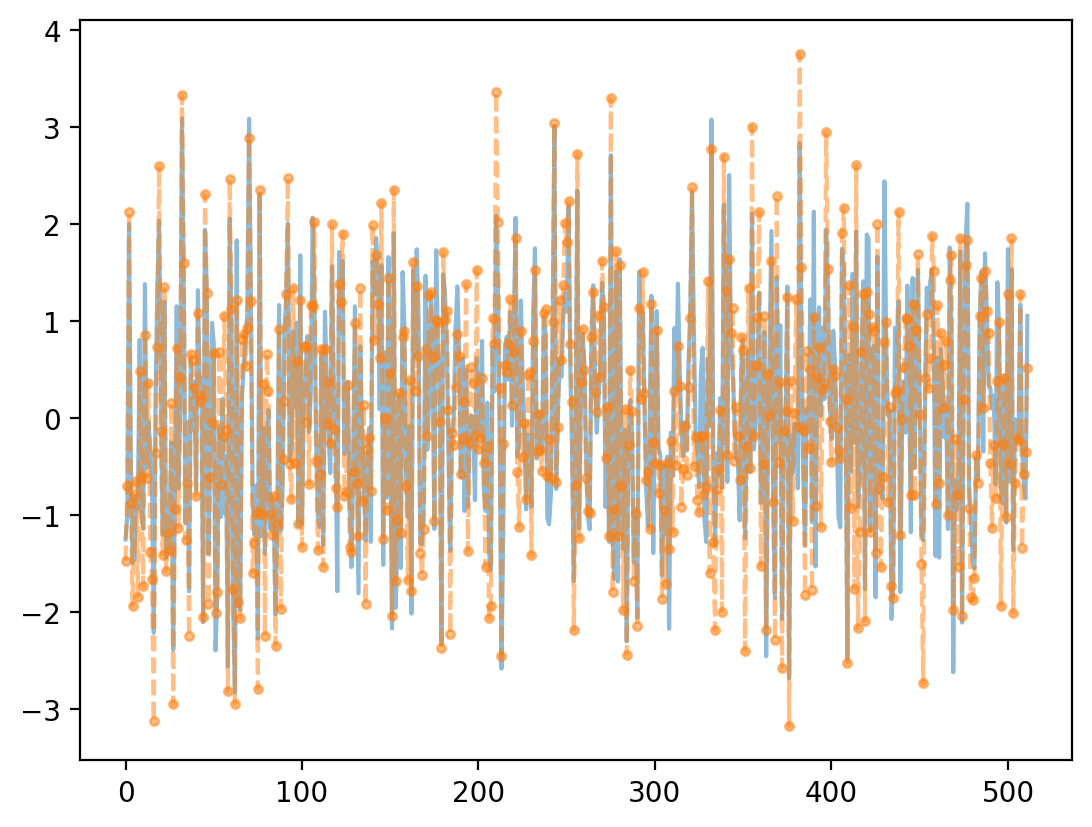

In [36]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [37]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([2, 12])
torch.Size([2, 12])


In [38]:
sorted_x_idxs = np.argsort(y_graph[:,0])
# sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

sorted_y_idxs = np.argsort(y_graph[:,1])
# sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[819 827 880 ... 239 385 162]
nott_28_[4, 6]<br>b_D:min_@4_m[9, 2, 11, 7]<br>b_D:maj_@2_m[9, 11, 6, 7]<br>A:min_@2_m[0, 11, 4]<br>
gjt_12_[0, 2]<br>b_E:maj7_@4_m[3, 4]<br>b_A#:7_@4_m[2]<br>
[824 816 547 ... 621 818 821]
nott_28_[9, 11]<br>b_A:min_@2_m[9, 11, 4, 7]<br>G:7_@2_m[0, 9, 4, 7]<br>b_C:maj_@4_m[0, 4, 7]<br>
nott_28_[6, 8]<br>b_G:7_@2_m[0, 9, 2, 11]<br>C:maj_@2_m[0, 4, 7]<br>b_A:min_@2_m[0, 2, 4, 5]<br>D:min_@2_m[0, 2, 11]<br>


In [39]:
graph_seqs = ''

# print left-most
print('left-most chord sequences:')
graph_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print right-most
print('right-most chord sequences:')
graph_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
graph_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
graph_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print top-most
print('top-most chord sequences:')
graph_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
D:min  D:maj A:min  
G:maj  G:maj G:7  
G:7  G:7 C:7  
G:7  E:min7 A:7  
C:7 F:maj  F:maj  
G:maj G:7  G:7 C:maj  
G:maj E:maj  A:min  
G#:7 G:sus4  C:maj6  
E:min E:min7  A:min  
F:maj  G:min C:7  
G:maj D:min  G:maj  
G#:hdim7 C#:7  F#:hdim7  
C:maj7  G#:7 G:sus4  
B:aug E:7  A:min7  
D:min E:7  A:min  
F:maj7 E:min7  A:maj  
A:min D:min  D:min  
C:maj  C:maj A:min  
G:7  C:maj7 C:dim7  
F:maj  A#:maj C:7  

right-most chord sequences:
E:maj7  A#:7  
F:maj7  A#:7  
A:min11  A#:min11  
A:min7  E:7(b9)  
E:sus4  E:7(b9)  
A:min  G:7  
F:9  A#:9  
A:min  E:7  
D:min9  G:13  
A#:7  A#:7  
A#:maj7  A#:maj7  
C:min  D#:9  
A:min11  A:min11  
A#:maj7  D#:7  
A:min6  G:min7  
G:sus4  G:sus4  
G#:maj7  A:maj7  
A:maj7  A#:maj7  
G:min7  C:9  
B:hdim7  E:7(b9)  

bottom-most chord sequences:
A:min G:7  C:maj  
C:maj G:7  A:min  
A:min  G:maj A:min  
F:maj G:7  C:maj  
F:maj  G:7 C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj

In [40]:
print(graph_seqs)

left-most chord sequences:
D:min  D:maj A:min  
G:maj  G:maj G:7  
G:7  G:7 C:7  
G:7  E:min7 A:7  
C:7 F:maj  F:maj  
G:maj G:7  G:7 C:maj  
G:maj E:maj  A:min  
G#:7 G:sus4  C:maj6  
E:min E:min7  A:min  
F:maj  G:min C:7  
G:maj D:min  G:maj  
G#:hdim7 C#:7  F#:hdim7  
C:maj7  G#:7 G:sus4  
B:aug E:7  A:min7  
D:min E:7  A:min  
F:maj7 E:min7  A:maj  
A:min D:min  D:min  
C:maj  C:maj A:min  
G:7  C:maj7 C:dim7  
F:maj  A#:maj C:7  

right-most chord sequences:
E:maj7  A#:7  
F:maj7  A#:7  
A:min11  A#:min11  
A:min7  E:7(b9)  
E:sus4  E:7(b9)  
A:min  G:7  
F:9  A#:9  
A:min  E:7  
D:min9  G:13  
A#:7  A#:7  
A#:maj7  A#:maj7  
C:min  D#:9  
A:min11  A:min11  
A#:maj7  D#:7  
A:min6  G:min7  
G:sus4  G:sus4  
G#:maj7  A:maj7  
A:maj7  A#:maj7  
G:min7  C:9  
B:hdim7  E:7(b9)  

bottom-most chord sequences:
A:min G:7  C:maj  
C:maj G:7  A:min  
A:min  G:maj A:min  
F:maj G:7  C:maj  
F:maj  G:7 C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj

In [41]:
# sorted_x_idxs = np.argsort(y_graph[:,0])
sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

# sorted_y_idxs = np.argsort(y_graph[:,1])
sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[829 837 830 ... 290 167 168]
nott_29_[1, 3]<br>b_G:maj_@2_m[2, 11]<br>C:maj_@2_m[0]<br>b_G:maj_@4_m[0, 2, 11, 4]<br>
gjt_12_[6, 8]<br>b_E:maj7_@2_m[8, 1, 11]<br>F#:min7_@1_m[4]<br>B:sus4_@1_m[4]<br>b_E:maj6_@2_m[1]<br>F#:min7_@1_m[1]<br>B:7_@1_m[]<br>
[795 796 210 ... 488  74 492]
nott_26_[2, 4]<br>b_C:maj_@2_m[0, 4]<br>F:maj_@2_m[2, 5]<br>b_C:maj_@1_m[0, 4]<br>G:7_@1_m[2, 11]<br>C:maj_@2_m[0, 5, 7]<br>
nott_6_[11, 13]<br>b_A:min_@4_m[0, 9, 11, 4]<br>b_A:min_@4_m[8, 9, 7]<br>


In [42]:
bilstm_seqs = ''

# print left-most
print('left-most chord sequences:')
bilstm_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print right-most
print('right-most chord sequences:')
bilstm_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
bilstm_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
bilstm_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print top-most
print('top-most chord sequences:')
bilstm_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
G:maj C:maj  G:maj  
G:maj  C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj  G:maj  
C:maj  C:maj G:maj  
G:maj C:maj  C:maj  
G:maj  G:maj  
C:maj F:maj  C:maj G:maj  
F:maj  G:maj C:maj  
C:maj  F:maj G:maj  
G:maj C:maj  F:maj  
F:maj C:maj  C:maj  
C:maj  F:maj C:maj  
C:maj F:maj  C:maj  
C:maj  F:maj C:maj  

right-most chord sequences:
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
F#:hdim7  E:maj7 F#:min7 B:sus4  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
A:9  A:9  
A:min11  A:min11  
A:maj7 F#:min7  B:min7 E:7  
B:min7 E:7  A:maj7 F#:min7  
E:hdim7  A:7 A:7(b13)  
A:7 A:7(b13)  D:9  
E:sus4  E:7(b9)  
C#:min7 F#:7  B:min7 E:7  
D#:maj7  E:13 D#:7  
A:min11  A#:min11  
E:maj7 B:min7 E:7  D#:min7 G#:7  
A:maj6  A:maj6  
E:min7  A:13  
G#:7 G:13  E:min7 A:7  
D#:maj7  F#:min7 B:7(b13)  
D:9  G#:7 G:13  

bottom-most chord sequence

In [43]:
print(bilstm_seqs)

left-most chord sequences:
G:maj C:maj  G:maj  
G:maj  C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj  G:maj  
C:maj  C:maj G:maj  
G:maj C:maj  C:maj  
G:maj  G:maj  
C:maj F:maj  C:maj G:maj  
F:maj  G:maj C:maj  
C:maj  F:maj G:maj  
G:maj C:maj  F:maj  
F:maj C:maj  C:maj  
C:maj  F:maj C:maj  
C:maj F:maj  C:maj  
C:maj  F:maj C:maj  

right-most chord sequences:
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
F#:hdim7  E:maj7 F#:min7 B:sus4  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
A:9  A:9  
A:min11  A:min11  
A:maj7 F#:min7  B:min7 E:7  
B:min7 E:7  A:maj7 F#:min7  
E:hdim7  A:7 A:7(b13)  
A:7 A:7(b13)  D:9  
E:sus4  E:7(b9)  
C#:min7 F#:7  B:min7 E:7  
D#:maj7  E:13 D#:7  
A:min11  A#:min11  
E:maj7 B:min7 E:7  D#:min7 G#:7  
A:maj6  A:maj6  
E:min7  A:13  
G#:7 G:13  E:min7 A:7  
D#:maj7  F#:min7 B:7(b13)  
D:9  G#:7 G:13  

bottom-most chord sequence

In [44]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': 'Can you commend on sequences of musical chords? \
        For example, which chord sequence is more common: a) G:7 C:maj7 or b)C#:7 C:maj7?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
# print(response.message.content)

When it comes to evaluating the relative popularity of two chord progressions in music, several factors can come into play. However, let's analyze your examples focusing on their harmonic and contextual implications.

### Example a) G:7 C:maj7

1. **Relative Major Seventh Chord**: A `Cmaj7` chord built on the root note `G` (in G major) would be `G - Bb - D - F`. This progression might sound less common because it implies a transition from `G` to `Bb`, which is not as smooth or expected in traditional harmonic progressions. The `Cmaj7` chord doesn't provide a strong dominant function that typically leads well to the tonic `G`.

2. **Chord Function**: The progression `G:7 C:maj7` could be used for its dissonant and unresolved quality, creating tension that might be more challenging or avant-garde in nature rather than accessible to mainstream audiences.

### Example b) C#:7 C:maj7

1. **Relative Minor Seventh Chord**: A `Cmaj7` chord built on the root note `C#` (in C# minor) would be `C#

In [45]:
response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': f'You are a music harmony expert and you role is to provide \
    comments on chord progressions that appear within two PCA-projected spaces. \
    These PCA spaces were produced by two models that process symbolic music \
    harmony and we are interested in explaining whether there is something \
    specific that the first two axes represent (left-right and bottom-top). \
    These spaces were formed by the same short chord sequences and we only use \
    the ones on the extreme edges in the analysis.\
    We are interested in understanding if Model 1 or Model 2 \
    have generated more musically meaningful representations and what those representations are about. \
    Keep in mid that both Models are trained on pieces in C major and A minor \
    and that the sequences they processes are segments of C major - A minor pieces. \
    Below are the Sets positioned in the respective PCA spaces by each model. \
    Here is Set 1 by model 1: `{bilstm_seqs}`. \n\n \
    Here is Set 2 by model 2: `{graph_seqs}`.\n \
    What information is broadly encoded by those two models? Is any representation \
    more meaningful, useful, deeper, more informative etc?',
  },
])
print(response['message']['content'])

To compare the representations generated by Model 1 and Model 2 in terms of their broad encoding and musical informativeness, we need to analyze both sets of chord sequences positioned at the extreme edges within the PCA spaces. Let's break down the analysis step-by-step.

### Common Elements and Differences

#### Chord Progressions
Both models generate chord progressions that are derived from C major and A minor scales. However, there are notable differences in the specific chords used and their harmonizations:

1. **C Major Context:**
   - Model 1 predominantly uses major chords (e.g., G:maj, C:maj).
   - Model 2 incorporates both major and minor chords within the context of C major (e.g., D:min, F:maj).

2. **A Minor Context:**
   - Both models use A minor and its related chords (e.g., A:min7, F#:min7) but vary in their usage.

3. **Sus4 Chords:**
   - Model 1 frequently uses sus4 chords (e.g., C:maj G:maj, E:maj6 F#:min7 B:sus4).
   - Model 2 also uses sus4 chords but sometimes inc